# P8: Classifier

Build an interpretable classifier: two labelled sets of sequences in, a **working predictor that tells you why** out. This protocol chains the standard AAanalysis pipeline end-to-end (split each sequence into *parts*, mine a *CPP signature*, assemble a numeric *feature matrix*, and fit a `TreeModel`) into a classifier whose every input is a human-readable `PART-SPLIT-SCALE` feature id tied to an AAontology physicochemical property. You read out *which* determinants drive each call, not just a score.

It is the direct successor to **P1: CPP signature**: Protocol 1 *discovers* the determinants that distinguish a **test group** (`label=1`) from a **reference group** (`label=0`); here we *use* that signature to predict, and rank the features by how hard the model leans on them.

> **Key mental model.** Interpretable features first, then the *simplest* model that does the job. Because every CPP feature is a named physicochemical property at a named sequence location, a plain tree ensemble on top of them is already a glass box, and you only believe it once it clearly **beats a trivial baseline**.

**When to use it.** Reach for this protocol when you have **two labelled sets of sequences** and want a model that not only predicts a new protein but names the physicochemistry behind the call. In glossary terms you are moving from **determinant discovery** (Protocol 1) to **prediction** (here, binary classification) with a `TreeModel` riding on interpretable CPP features instead of a black box.

We work at the **domain level** (dataset prefix `DOM_`): the **unit of comparison** is the transmembrane-domain (TMD) part set, CPP's native ground. The biological question: *given a transmembrane protein, is it a γ-secretase (GSEC) substrate, and which properties of its TMD and juxtamembrane (JMD) flanks drive that call?* Because every feature is a position-resolved physicochemical property (an AAontology scale evaluated at a part and split), the fitted importances **name the determinants**: they are not anonymous weights.

**When *not* to use it.**

- If you only want to know *what differs* between two groups and have no intention of scoring new proteins, stop at **P1: CPP signature**: you don't need a model.
- If you have **confirmed positives plus a large unlabelled pool** but few confirmed negatives, you cannot train a clean binary classifier directly; carve reliable negatives first (see the **PU note** near the end).
- If your goal is a leak-free generalization estimate, the light checks here are not enough: that is **P9: Validate**.

**Input.** The same `df_seq` that feeds **P1: CPP signature**: one row per protein, a binary `label` column (**test group** = 1 = substrate, **reference group** = 0 = non-substrate), and `tmd_start` / `tmd_stop` boundaries from which the TMD-centric **parts** are derived. The default `df_parts` uses the parts `tmd`, `jmd_n_tmd_n` and `tmd_c_jmd_c` (the TMD plus its two JMD-flank composites).

The CPP **signature** `df_feat` itself is the output of **P1: CPP signature**. To keep this protocol self-contained we re-run the minimal CPP path here on the bundled `DOM_GSEC` dataset.

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = non-substrate/reference)
df_seq = aa.load_dataset(name="DOM_GSEC", n=25)   # n per class -> 50 proteins (2N rows)
labels = df_seq["label"].to_list()
aa.display_df(df=df_seq, n_rows=5)

,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Run.** The real minimal path (no aspirational one-liners). For the mechanics of each function, see its tutorial (the CPP tutorial for `SequenceFeature` and `CPP`, the TreeModel tutorial for `TreeModel`); here we just chain them into a workflow:

1. Split each sequence into **parts** with `SequenceFeature.get_df_parts`.
2. Mine the discriminant **signature** with `CPP(df_parts=...).run(labels=...)`: `CPP` takes `df_parts`, **not** `df_seq` / `labels` directly.
3. Build the numeric **feature matrix** `X` with `SequenceFeature.feature_matrix`.
4. Fit the classifier with `TreeModel.fit(X, labels=...)` and attach the importance ranking with `add_feat_importance`.

In [2]:
# 1) Split each sequence into parts; default df_parts columns are
#    tmd, jmd_n_tmd_n, tmd_c_jmd_c (TMD plus the two JMD-flank composites).
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)

# 2) Mine the most discriminant features (the CPP signature).
#    n_jobs=1 keeps it serial (multiprocessing spawn is fragile on
#    Python 3.14 + macOS without a __main__ guard).
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=50, n_jobs=1)
aa.display_df(df=df_feat[["feature", "category", "subcategory", "abs_auc", "mean_dif"]], n_rows=5)

,feature,category,subcategory,abs_auc,mean_dif
1,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,0.426000,-0.266000
2,"TMD_C_JMD_C-Pat...,12)-BEGF750101",Conformation,α-helix,0.419000,0.225000
3,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",Conformation,β-turn,0.408000,-0.312000
4,"TMD-Pattern(C,4...,11)-BEGF750101",Conformation,α-helix,0.396000,0.238000
5,"TMD_C_JMD_C-Pat...,14)-ZIMJ680104",Energy,Isoelectric point,0.391000,0.129000


In [3]:
# 3) Build the feature matrix X and fit the interpretable classifier.
#    feature_matrix turns each PART-SPLIT-SCALE feature into one averaged
#    numeric value per protein -> X has shape (n_proteins, n_features).
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts, n_jobs=1)

# TreeModel aggregates several tree models over several rounds; .fit sets
# feat_importance, is_selected_ and list_models_ (defaults: n_rounds=5, no RFE).
tm = aa.TreeModel(verbose=False, random_state=42)
tm = tm.fit(X, labels=labels)

# Attach the Monte-Carlo feature importance (percent) as a column.
df_feat = tm.add_feat_importance(df_feat=df_feat)
aa.display_df(df=df_feat[["feature", "subcategory", "abs_auc", "mean_dif", "feat_importance"]], n_rows=5)

,feature,subcategory,abs_auc,mean_dif,feat_importance
1,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",β-turn,0.426000,-0.266000,4.074000
2,"TMD_C_JMD_C-Pat...,12)-BEGF750101",α-helix,0.419000,0.225000,5.689000
3,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",β-turn,0.408000,-0.312000,3.697000
4,"TMD-Pattern(C,4...,11)-BEGF750101",α-helix,0.396000,0.238000,1.910000
5,"TMD_C_JMD_C-Pat...,14)-ZIMJ680104",Isoelectric point,0.391000,0.129000,0.829000


**Output.** A few things came out of that run:

- a **fitted `TreeModel`** carrying `feat_importance` / `feat_importance_std` (group-level importance, percent), `is_selected_` (per-round selection) and `list_models_` (the fitted estimators);
- an **enriched `df_feat`**, the CPP **signature** plus a `feat_importance` column, so each determinant is ranked;
- a **`df_eval`** row of cross-validated metric means (below);
- **per-protein substrate probabilities** with a Monte-Carlo spread.

The quickest way to *see* the classifier is the **CPP ranking plot**: the top determinants, how strongly each separates the two groups (`mean_dif`, left), and how hard the model leans on each (`feat_importance`, gray). This is the protocol's key figure: it reads as a ranked list of *named* physicochemical determinants, not anonymous weights.

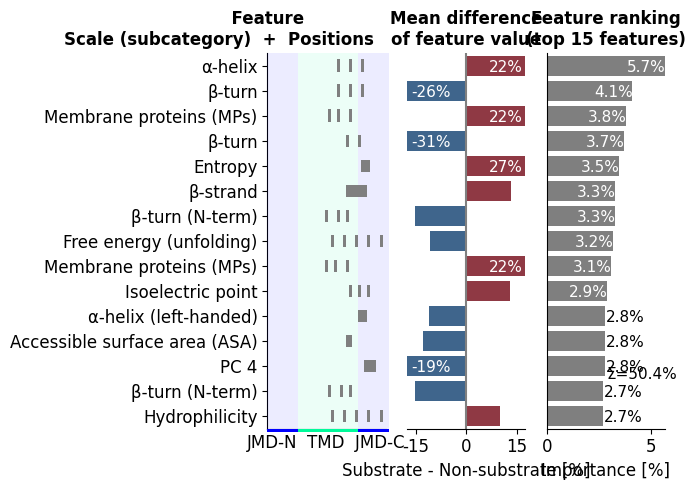

In [4]:
import matplotlib.pyplot as plt

# Key figure: the top determinants the fitted classifier relies on.
# Left subplot = group difference (mean_dif); gray bars = group-level feat_importance.
cpp_plot = aa.CPPPlot()
fig, axes = cpp_plot.ranking(df_feat=df_feat, n_top=15,
                             name_test="Substrate", name_ref="Non-substrate")
plt.tight_layout()
plt.show()

Notice how the top bars are TMD/JMD physicochemical patterns, named `PART-SPLIT-SCALE` determinants, not anonymous weights. In the rendered plot, the left panel shows each feature's `mean_dif` (which way it points: bars to the right sit higher in substrates, bars to the left higher in non-substrates), while the gray `feat_importance` bars on the right show how hard the fitted model leans on each one. Read the two together: bar *height* (gray) tells you *how much* a determinant matters, and `mean_dif` *direction* (left) tells you *which way*.

**Honest evaluation hooks (light).** A figure shows *what* the model leans on; these three quick checks tell you whether it is non-trivial. They are **not** a substitute for validation:

1. **Cross-validated metrics** via `TreeModel.eval` over the fitted feature set (`fit` ran with `use_rfe=False`, so all features are kept).
2. **A trivial baseline**, a majority-class `DummyClassifier`; a real model must beat its ~0.5 balanced accuracy.
3. **Per-protein probabilities** via `TreeModel.predict_proba` (a mean score and its Monte-Carlo std).

**Read these numbers as an optimistic upper bound, not an unbiased estimate.** The CPP signature was mined with `labels` on the *whole* 50-protein dataset, then this CV reuses exactly those globally-selected feature columns, so each fold's features were chosen using proteins that also sit in that fold's test split (feature-selection leakage). It is a sanity check / ceiling, not a generalization estimate. Leak-free nested or hold-out evaluation plus shuffled-label controls live in **P9: Validate**.

To actually *reduce* the feature set (recursive feature elimination) rather than keep all features, fit with `TreeModel(...).fit(X, labels, use_rfe=True)` or call `select_features`; `is_selected_` then marks the retained subset.

In [5]:
# Cross-validated performance of the full fitted feature set (use_rfe=False
# keeps all features; is_selected_ is all-True). Optimistic: the CPP features
# were selected on the full dataset, so this is an upper bound, not a clean
# generalization estimate (see Protocol 9 for leak-free validation).
df_eval = tm.eval(X,
                  labels=labels,
                  list_is_selected=[tm.is_selected_],
                  list_metrics=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
                  n_cv=5)

# Trivial majority-class baseline for comparison (~0.5 balanced accuracy).
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline_bacc = cross_val_score(
    DummyClassifier(strategy="most_frequent"),
    X, labels, cv=5, scoring="balanced_accuracy").mean()

aa.display_df(df=df_eval.assign(baseline_balanced_accuracy=round(float(baseline_bacc), 3)))

,name,accuracy,balanced_accuracy,f1,roc_auc,baseline_balanced_accuracy
1,Set 1,0.920000,0.920000,0.925300,0.984000,0.500000


In [6]:
# Per-protein predicted probability of being a substrate (requires prior fit).
import pandas as pd

pred, pred_std = tm.predict_proba(X)
df_pred = pd.DataFrame({
    "entry": df_seq["entry"].to_list(),
    "label": labels,
    "p_substrate": pred.round(3),
    "p_std": pred_std.round(3),
})
# These are IN-SAMPLE (training) predictions, shown only to demonstrate the
# output shape -- they say nothing about generalization. p_std is the spread
# across the ensemble (all tree models over all rounds), i.e. agreement, NOT
# held-out confidence: a small p_std means the models concur, not that the call
# is correct on unseen data. Score real, unseen proteins to judge generalization
# (see Protocol 9).
aa.display_df(df=df_pred.sort_values("p_substrate", ascending=False), n_rows=5)

,entry,label,p_substrate,p_std
34,P19022,1,1.000000,0.000000
30,Q06481,1,1.000000,0.000000
44,Q9ERC8,1,1.000000,0.000000
33,P09803,1,1.000000,0.000000
36,P09603,1,1.000000,0.000000


**How to interpret.**

| Output | Non-expert reading |
| --- | --- |
| `balanced_accuracy` clearly above the ~0.5 baseline | the selected TMD/JMD physicochemistry is *plausibly* discriminative, confirm with leak-free validation in **P9: Validate** (this light CV is an optimistic upper bound) |
| high `roc_auc` | the model ranks substrates above non-substrates reliably |
| high `feat_importance` (tall gray bar in the ranking plot) | the determinant the model **leans on most** for the call |
| sign of `mean_dif` for that feature | **direction** of the effect (positive = property higher in substrates) |
| `p_substrate` near 1 (or 0) | a substrate (or non-substrate) call; in-sample here, so judge confidence only on unseen proteins |
| large `p_std` | an unstable prediction (the ensemble models disagree) |

`feat_importance` is **unsigned** (magnitude of influence only). Always pair it with `mean_dif` from the CPP **signature** to recover the biological direction, e.g. *higher side-chain volume in the TMD core* rather than just *side-chain volume matters*.

**Key takeaways**

- The classifier is a **glass box**: each input is a named `PART-SPLIT-SCALE` determinant, so a tall `feat_importance` bar points at a concrete physicochemical property at a concrete sequence location, read with the sign of `mean_dif` for direction.
- A model is only worth interpreting once it **clearly beats the ~0.5 baseline**; here balanced accuracy sits well above it.
- These numbers are an **optimistic ceiling** (feature-selection leakage), so treat the result as "plausibly discriminative" and defer real trust to **P9: Validate**.

**Common mistakes.**

- **`CPP(df_seq=...)` / `CPP().run(df_seq, labels)`**: `CPP` takes `df_parts`; build them with `SequenceFeature.get_df_parts` first.
- **Skipping the feature matrix**: `TreeModel.fit` needs numeric `X` from `SequenceFeature.feature_matrix`, not `df_feat` or `df_seq`.
- **Reading `feat_importance` as signed**: it is magnitude only; combine with `mean_dif` for direction.
- **Calling `predict_proba` or `add_feat_importance` before `fit`**: both rely on attributes set during `.fit`.
- **Mistaking light eval for validation**: the CV row and baseline here are sanity checks; rigorous trust-building is **P9: Validate**.
- **Mis-using `dPULearn`**: it expects labels **1 (positive) and 2 (unlabelled)**, not 0/1, and `n_unl_to_neg` must be **>= 1 and must not exceed** the number of unlabelled samples.

**PU note: when confirmed negatives are scarce.** Real GSEC datasets often have **confirmed substrates (positives, label 1)** but few confirmed non-substrates; the rest are **unlabelled (label 2)**. You cannot train a clean binary classifier on positives-plus-unlabelled directly.

`dPULearn` (core, no pro dependency) solves the first half: from the unlabelled pool it identifies **reliable negatives (label 0)**, the proteins most dissimilar from the positives in CPP feature space, which you can then feed to the classifier above. See the dPULearn tutorial for the method details.

Because CPP feature identifiers are **dataset-independent strings**, the *same* `df_feat["feature"]` builds the feature matrix for the PU proteins. We demonstrate on the bundled `DOM_GSEC_PU` dataset, then visualize the carve with the canonical **dPULearn PCA**: positives, the newly carved reliable negatives, and the still-unlabelled pool laid out in the first two principal components of CPP feature space.

In [7]:
# Positives (1) + unlabelled (2): n=20 -> 20 positives and 20 unlabelled.
df_seq_pu = aa.load_dataset(name="DOM_GSEC_PU", n=20)
labels_pu = df_seq_pu["label"].to_list()

# Reuse the SAME CPP feature ids to build X for the PU proteins.
df_parts_pu = sf.get_df_parts(df_seq=df_seq_pu)
X_pu = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts_pu, n_jobs=1)

# Carve reliable negatives (0) from the unlabelled pool (2).
# n_unl_to_neg must be >= 1 and must not exceed the number of unlabelled samples (<= 20 here).
# n_components=5 keeps several leading PCs so the carve is visualizable as a PC1-vs-PC2 PCA.
dpul = aa.dPULearn(verbose=False, random_state=42)
dpul = dpul.fit(X=X_pu, labels=labels_pu, n_unl_to_neg=10, n_components=5)

# labels_: 1 = positive, 0 = newly identified reliable negative, 2 = still unlabelled.
import collections
collections.Counter(dpul.labels_.tolist())

Counter({1: 20, 2: 10, 0: 10})

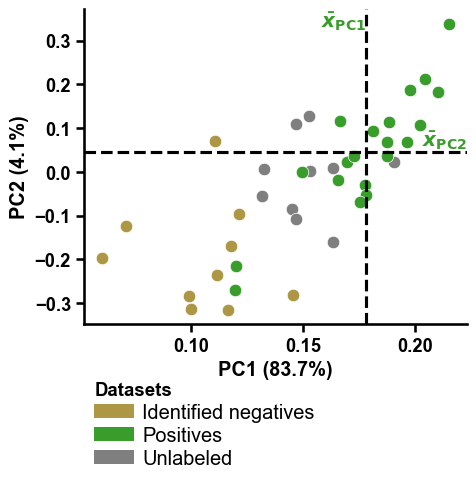

In [8]:
# Headline figure: the dPULearn PCA. The PU proteins are projected into the
# first two principal components of CPP feature space. Dashed lines mark the
# positive-class mean per PC; the unlabelled points (2) furthest from it are
# carved as reliable negatives (0), which then feed the classifier above.
df_pu = dpul.df_pu_
labels_carved = dpul.labels_

aa.plot_settings(font_scale=0.8)
aa.dPULearnPlot().pca(df_pu=df_pu, labels=labels_carved)
plt.tight_layout()
plt.show()

**Next step.** To explain a single prediction down to per-sample, single-residue contributions (`ShapModel`, sample-level `CPPPlot.feature_map`), continue to **P9: Interpretability**.